In [24]:
import scanpy as sc
import pandas as pd

In [8]:
anmatrix = sc.read_10x_mtx('./Data', var_names='gene_symbols', make_unique=True, compressed=False)

In [18]:
import re, scipy.io, pandas as pd, anndata as ad

X = scipy.io.mmread('./proteinData/matrix.mtx').T.tocsr()
barcodes = pd.read_csv('./proteinData/barcodes.tsv', header=None, sep='\t')[0]
feat = pd.read_csv('./proteinData/features.tsv', header=None, sep='\t')[0]

# remove the trailing "-ACGT..." tag sequence
names = feat.str.replace(r'-[ACGT]{10,}$', '', regex=True)

# make into an annData object
protein = ad.AnnData(X=X,
                     obs=pd.DataFrame(index=barcodes.values),
                     var=pd.DataFrame(index=names.values))
protein.var['antibody_tag'] = feat.values   # keep the original for reference
print(protein)
print(list(protein.var_names))

AnnData object with n_obs × n_vars = 737243 × 63
    var: 'antibody_tag'
['CD80', 'CD274', 'CD275', 'CD3', 'CD19', 'CD138', 'CD45RA', 'CD14', 'CD16', 'CD25', 'CD45RO', 'CD279', 'CD20', 'IgM', 'CD5', 'CD32', 'CD196', 'CD185', 'CD69', 'CD62L', 'CD152', 'CD223', 'KLRG1', 'CD27', 'HLA-DR', 'CD314', 'CD272', 'CD278', 'CD24', 'CD21', 'IgA', 'CD268', 'CD267', 'IgER', 'CD124', 'CD184', 'CD29', 'IgD', 'CD38', 'CD22', 'CD193', 'CD307d', 'CD307e', 'CD289', 'CD74', 'CD11c', 'B2M', 'CD119', 'CD197', 'CD183', 'CD86', 'CD284', 'IgG', 'CD88', 'CCP1', 'CCP2', 'CCP3', 'CCP4', 'CCP5', 'CCP6', 'CCP7', 'CCP8', 'unmapped']


In [21]:
# anmatrix = cells x genes (19k x 36k)
# protein = cells x proteins (74k x 63) - lots of empty droplet cells

CD80         CD80-ACGAATCAATCTGTG
CD274       CD274-GTTGTCCGACAATAC
CD275       CD275-GTGCATTCAACAGTA
CD3           CD3-CTCATTGTAACTCCT
CD19         CD19-CTGGGCAATTACTCG
                    ...          
CCP5         CCP5-TCTCTCTGCGATTCC
CCP6         CCP6-CGTCCTTTGCCTGTA
CCP7         CCP7-AACCTTTGCCACTGC
CCP8         CCP8-GGTTGTCATAAGAAC
unmapped                 unmapped
Name: antibody_tag, Length: 63, dtype: object

In [62]:
# filter and order protein and rna objects by common cells

rnaCells=anmatrix.obs_names
proteinCells=protein.obs_names
intersection = list(set(rnaCells) & set(proteinCells))
len(intersection)

rnaData = anmatrix[anmatrix.obs_names.isin(intersection), :].copy()
proteinData = protein[protein.obs_names.isin(intersection), :].copy()

rnaData = rnaData[rnaData.obs_names.sort_values(), :].copy()
proteinData = proteinData[proteinData.obs_names.sort_values(), :].copy()
print(rnaData)
print(proteinData)

AnnData object with n_obs × n_vars = 19683 × 36617
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 19683 × 63
    var: 'antibody_tag'


In [69]:
# checking if the proteins match CAPTAIN's vocabulary 
import pickle
with open('csp_token_dict.pickle', 'rb') as file:
    a = pickle.load(file)


In [81]:
keys = set(a.keys())
pr = set(proteinData.var_names)
i = keys.intersection(pr)
len(i), len(pr), len(keys)

(49, 63, 387)

In [84]:
# Quality Control (from Scanpy's preprocessing tutorial)

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
rnaData.var["mt"] = rnaData.var_names.str.startswith("MT-")
# ribosomal genes
rnaData.var["ribo"] = rnaData.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
rnaData.var["hb"] = rnaData.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(rnaData, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

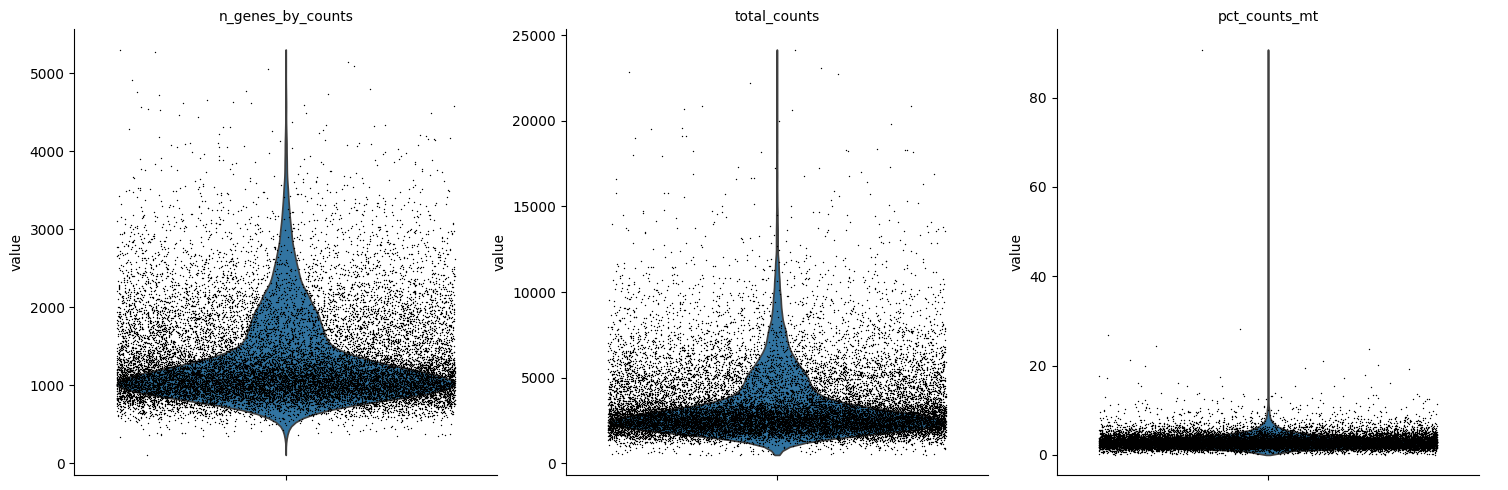

In [85]:
sc.pl.violin(
    rnaData,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [13]:
# understanding the data 
anmatrix.var['feature_types'].value_counts()
print(anmatrix.var_names[:10])          # should be gene symbols like MIR1302-2HG, FAM138A
print(anmatrix.X[:5, :20].toarray())    # should be whole numbers, mostly zeros
print(anmatrix.X.max())                 # a large whole number
print(anmatrix.obs_names[:5])   # rows: should be barcodes like 'AAACCTGAGCATCATC-1'
print(anmatrix.var_names[:5])   # columns: should be genes like 'MIR1302-2HG'

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1'],
      dtype='object')
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
6734.0
